In [2]:
import numpy as np
import matplotlib.pyplot as plt

from piwavelet.wavelets.morlet import Morlet

from piwavelet.transforms.cwt import cwt
from piwavelet.transforms.icwt import icwt

from piwavelet.statistics.ar1 import estimate_ar1
from piwavelet.statistics.significance import scale_averaged_significance

from piwavelet.smoothing.operators import smooth_wavelet

from piwavelet.plotting.wavelet import (
    ContinuousWaveletResult,
    plot_wavelet,
)

from piwavelet.transforms.cwt import cwt

In [ ]:
np.random.seed(42)

N = 2048
dt = 0.25

t = np.arange(N) * dt

signal_1 = np.sin(2 * np.pi * t / 16)
signal_2 = 0.5 * np.sin(2 * np.pi * t / 64)

modulation = 1 + 0.4 * np.sin(2 * np.pi * t / 256)

noise = 0.3 * np.random.randn(N)

x = modulation * (signal_1 + signal_2) + noise

x = (x - x.mean()) / x.std()

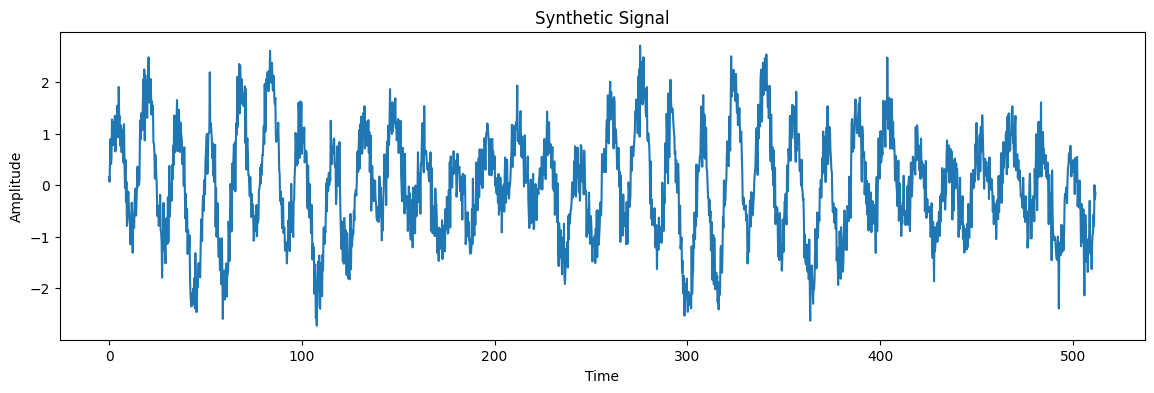

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(t, x)
ax.set_title("Synthetic Signal")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")

plt.show()

In [ ]:
mother = Morlet(f0=6)

dj = 1 / 12
s0 = -1
J = -1

result = cwt(
    signal=x,
    dt=dt,
    dj=dj,
    s0=s0,
    J=J,
    wavelet=mother,
)

In [ ]:
wave = result.signal
scales = result.scales
freqs = result.frequencies
coi = result.coi
signal_fft = result.fft
fft_freqs = result.fft_frequencies

In [ ]:
power = np.abs(wave) ** 2
period = 1 / freqs

TypeError: Input z must be at least a (2, 2) shaped array, but has shape (0, 2048)

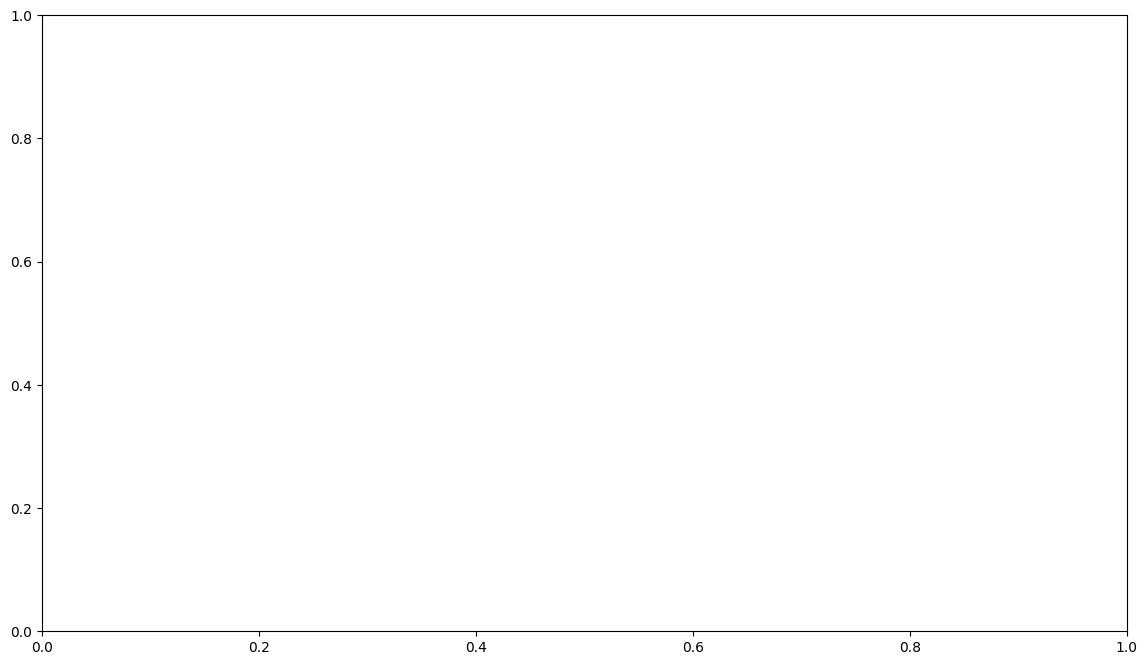

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from piwavelet.plotting.wavelet import (
    ContinuousWaveletResult,
    plot_wavelet,
)

from piwavelet.transforms.cwt import cwt


# ----------------------------------------------------------------------
# synthetic signal
# ----------------------------------------------------------------------

dt = 0.25

time = np.arange(0, 512) * dt

signal = (
    np.sin(2 * np.pi * time / 16)
    + 0.5 * np.sin(2 * np.pi * time / 64)
)

signal += 0.2 * np.random.randn(time.size)

normalized_signal = (
    signal - signal.mean()
) / signal.std()


# ----------------------------------------------------------------------
# compute cwt
# ----------------------------------------------------------------------

result = cwt(
    signal=normalized_signal,
    dt=dt,
    time=time,
)


# ----------------------------------------------------------------------
# classical wavelet diagnostics
# ----------------------------------------------------------------------

power = np.abs(result.coefficients) ** 2

global_power = power.mean(axis=1)

fft_power = (
    np.abs(result.fft[: result.n_padded // 2]) ** 2
)

fft_frequencies = (
    result.fft_frequencies[: result.n_padded // 2]
)

positive = fft_frequencies > 0

fft_power_full = np.zeros_like(result.frequencies)

interp_fft = np.interp(
    result.frequencies,
    fft_frequencies[positive],
    fft_power[positive],
    left=np.nan,
    right=np.nan,
)

fft_power_full[:] = interp_fft


# ----------------------------------------------------------------------
# placeholder significance
# replace later with proper red-noise significance
# ----------------------------------------------------------------------

significance = np.ones_like(power)

global_significance = np.ones_like(
    result.periods
)


# ----------------------------------------------------------------------
# plotting container
# ----------------------------------------------------------------------

plot_result = ContinuousWaveletResult(
    time=time,
    signal=signal,
    normalized_signal=normalized_signal,
    coefficients=result.coefficients,
    power=power,
    global_power=global_power,
    fft_power=fft_power_full,
    periods=result.periods,
    frequencies=result.frequencies,
    scales=result.scales,
    coi=result.coi,
    significance=significance,
    global_significance=global_significance,
    wavelet_name=type(result.wavelet).__name__,
)


# ----------------------------------------------------------------------
# plot
# ----------------------------------------------------------------------

fig = plot_wavelet(
    plot_result,
    title="Synthetic Signal",
    signal_label="Amplitude",
    show_scale_average=False,
)

plt.show()